# 04 - Optimización de Hiperparámetros

Optimización de hiperparámetros usando GridSearchCV y RandomizedSearchCV para los mejores modelos identificados.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib
import json

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (make_scorer, f1_score, roc_auc_score, 
                           classification_report, confusion_matrix)

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from data_preprocessing import load_processed_data, encode_categorical_features
from hyperparameter_tuning import (get_param_grids, run_grid_search, 
                                   run_randomized_search, compare_results)

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12
RANDOM_STATE = 42

## 1. Carga de Datos

In [3]:
# Cargar datos
df = load_processed_data()

X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

# Codificar y escalar
X_encoded, _ = encode_categorical_features(X)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos preparados: Train {X_train.shape}, Test {X_test.shape}")

Columnas codificadas: 16
Datos preparados: Train (800, 27), Test (200, 27)


## 2. Definición de Espacios de Búsqueda

In [4]:
# Obtener grids de parámetros
param_grids = get_param_grids()

print("Espacios de búsqueda definidos:")
for model_name, grid in param_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Espacios de búsqueda definidos:

Random Forest:
  n_estimators: [50, 100, 200]
  max_depth: [5, 10, 15, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Gradient Boosting:
  n_estimators: [50, 100, 200]
  learning_rate: [0.01, 0.1, 0.2]
  max_depth: [3, 5, 7]
  min_samples_split: [2, 5]
  subsample: [0.8, 1.0]

Logistic Regression:
  C: [0.001, 0.01, 0.1, 1, 10, 100]
  penalty: ['l1', 'l2']
  solver: ['liblinear', 'saga']

Decision Tree:
  max_depth: [3, 5, 10, 15, None]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 4, 8]
  criterion: ['gini', 'entropy']

SVM:
  C: [0.1, 1, 10, 100]
  kernel: ['rbf', 'linear', 'poly']
  gamma: ['scale', 'auto', 0.001, 0.01]

KNN:
  n_neighbors: [3, 5, 7, 11, 15]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan', 'minkowski']


## 3. Optimización con GridSearchCV

In [5]:
# Definir scorer (F1 para manejar desbalance)
scorer = make_scorer(f1_score, pos_label=1)

# Modelos a optimizar
models_to_tune = {
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
}

grid_results = {}

In [6]:
# Ejecutar GridSearchCV para Random Forest

rf_grid = run_grid_search(
    models_to_tune['Random Forest'],
    param_grids['Random Forest'],
    X_train,
    y_train,
    scorer,
    cv=3,
    n_jobs=-1
)

# Calcular score en test
from sklearn.metrics import f1_score
rf_best = rf_grid['best_model']
rf_test_pred = rf_best.predict(X_test)
rf_grid['test_score'] = f1_score(y_test, rf_test_pred)

grid_results['Random Forest'] = rf_grid

print(f"\nMejores parámetros: {rf_grid['best_params']}")
print(f"Mejor score CV: {rf_grid['best_score']:.4f}")
print(f"Score en test: {rf_grid['test_score']:.4f}")

Iniciando GridSearchCV con 5 parámetros...
Fitting 3 folds for each of 216 candidates, totalling 648 fits


Mejores parámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mejor score CV: 0.9950

Mejores parámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mejor score CV: 0.9950
Score en test: 0.9950


In [7]:
# Ejecutar GridSearchCV para Logistic Regression

lr_grid = run_grid_search(
    models_to_tune['Logistic Regression'],
    param_grids['Logistic Regression'],
    X_train_scaled,  # LR funciona mejor con datos escalados
    y_train,
    scorer,
    cv=3,
    n_jobs=-1
)

# Calcular score en test
lr_best = lr_grid['best_model']
lr_test_pred = lr_best.predict(X_test_scaled)
lr_grid['test_score'] = f1_score(y_test, lr_test_pred)

grid_results['Logistic Regression'] = lr_grid

print(f"\nMejores parámetros: {lr_grid['best_params']}")
print(f"Mejor score CV: {lr_grid['best_score']:.4f}")
print(f"Score en test: {lr_grid['test_score']:.4f}")

Iniciando GridSearchCV con 3 parámetros...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor score CV: 0.9994

Mejores parámetros: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor score CV: 0.9994
Score en test: 1.0000


c:\Users\dpere\OneDrive\Desktop\pplcdd\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\dpere\OneDrive\Desktop\pplcdd\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 4. Optimización con RandomizedSearchCV

In [8]:
random_results = {}

gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_random = run_randomized_search(
    gb_model,
    param_grids['Gradient Boosting'],
    X_train,
    y_train,
    scorer,
    n_iter=20,
    cv=3,
    random_state=RANDOM_STATE
)

# Calcular score en test
gb_best = gb_random['best_model']
gb_test_pred = gb_best.predict(X_test)
gb_random['test_score'] = f1_score(y_test, gb_test_pred)

random_results['Gradient Boosting'] = gb_random

print(f"\nMejores parámetros: {gb_random['best_params']}")
print(f"Mejor score CV: {gb_random['best_score']:.4f}")
print(f"Score en test: {gb_random['test_score']:.4f}")

Iniciando RandomizedSearchCV con 20 iteraciones...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores parámetros: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 7, 'learning_rate': 0.1}
Mejor score CV: 0.9962

Mejores parámetros: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 7, 'learning_rate': 0.1}
Mejor score CV: 0.9962
Score en test: 1.0000


In [9]:

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_random = run_randomized_search(
    dt_model,
    param_grids['Decision Tree'],
    X_train,
    y_train,
    scorer,
    n_iter=15,
    cv=3,
    random_state=RANDOM_STATE
)

# Calcular score en test
dt_best = dt_random['best_model']
dt_test_pred = dt_best.predict(X_test)
dt_random['test_score'] = f1_score(y_test, dt_test_pred)

random_results['Decision Tree'] = dt_random

print(f"\nMejores parámetros: {dt_random['best_params']}")
print(f"Mejor score CV: {dt_random['best_score']:.4f}")
print(f"Score en test: {dt_random['test_score']:.4f}")

Iniciando RandomizedSearchCV con 15 iteraciones...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Mejores parámetros: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy'}
Mejor score CV: 1.0000

Mejores parámetros: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy'}
Mejor score CV: 1.0000
Score en test: 1.0000


## 5. Comparación de Resultados

In [10]:
# Combinar resultados
all_results = {**grid_results, **random_results}

# Crear DataFrame comparativo
comparison_df = compare_results(all_results)

print("Comparación de Modelos Optimizados:")
print(comparison_df.to_string())

Comparación de Modelos Optimizados:
                          Search_Method  CV_Score  Test_Score                                                                                                  Best_Params
Modelo                                                                                                                                                                    
Decision Tree        RandomizedSearchCV  1.000000    1.000000                      {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy'}
Logistic Regression        GridSearchCV  0.999370    1.000000                                                            {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Gradient Boosting    RandomizedSearchCV  0.996222    1.000000        {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 7, 'learning_rate': 0.1}
Random Forest              GridSearchCV  0.994976    0.994975  {'max_depth': 5, 'max_features': 'sqrt', 'min_

In [11]:
# Guardar resultados de optimización
metrics_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'metrics')
results_path = os.path.join(metrics_dir, 'hyperparameter_tuning_results.csv')
comparison_df.to_csv(results_path)
print(f"\nResultados guardados: {results_path}")


Resultados guardados: c:\Users\dpere\OneDrive\Desktop\pplcdd\results\metrics\hyperparameter_tuning_results.csv


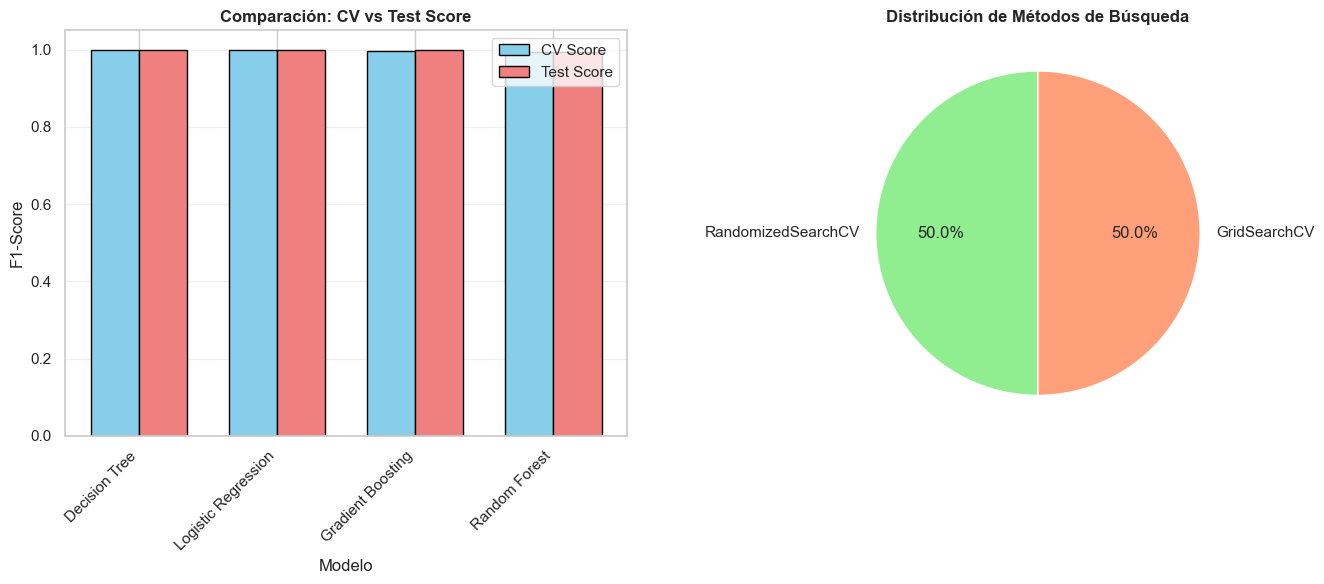

In [12]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CV Score vs Test Score (si existe)
x_pos = np.arange(len(comparison_df))
width = 0.35

# Verificar si Test_Score existe, si no, usar solo CV_Score
if 'Test_Score' in comparison_df.columns:
    axes[0].bar(x_pos - width/2, comparison_df['CV_Score'], width, 
               label='CV Score', color='skyblue', edgecolor='black')
    axes[0].bar(x_pos + width/2, comparison_df['Test_Score'], width, 
               label='Test Score', color='lightcoral', edgecolor='black')
else:
    axes[0].bar(x_pos, comparison_df['CV_Score'], width, 
               label='CV Score', color='skyblue', edgecolor='black')

axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Comparación: CV vs Test Score', fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df.index, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Método de búsqueda
method_counts = comparison_df['Search_Method'].value_counts()
axes[1].pie(method_counts.values, labels=method_counts.index, autopct='%1.1f%%',
         colors=['lightgreen', 'lightsalmon'], startangle=90)
axes[1].set_title('Distribución de Métodos de Búsqueda', fontweight='bold')

plt.tight_layout()

plots_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'plots')
plt.savefig(os.path.join(plots_dir, '18_hyperparameter_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Guardar Mejores Modelos Optimizados

In [13]:
# Guardar modelos optimizados
models_dir = os.path.join(os.path.dirname(os.getcwd()), 'models', 'trained_models')

for name, result in all_results.items():
    model_path = os.path.join(models_dir, f'{name}_optimized.joblib')
    joblib.dump(result['best_model'], model_path)
    print(f"Modelo optimizado guardado: {model_path}")
    
    # Guardar parámetros en JSON
    params_path = os.path.join(models_dir, f'{name}_best_params.json')
    with open(params_path, 'w') as f:
        json.dump(result['best_params'], f, indent=2)
    print(f"Parámetros guardados: {params_path}")

Modelo optimizado guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Random Forest_optimized.joblib
Parámetros guardados: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Random Forest_best_params.json
Modelo optimizado guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Logistic Regression_optimized.joblib
Parámetros guardados: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Logistic Regression_best_params.json
Modelo optimizado guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Gradient Boosting_optimized.joblib
Parámetros guardados: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Gradient Boosting_best_params.json
Modelo optimizado guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Decision Tree_optimized.joblib
Parámetros guardados: c:\Users\dpere\OneDrive\Desktop\pplcdd\models\trained_models\Decision Tree_best_params.json


## 7. Evaluación Final de Modelos Optimizados

In [14]:
# Evaluar cada modelo optimizado en el conjunto de test
final_results = {}

for name, result in all_results.items():
    model = result['best_model']
    
    # Seleccionar datos apropiados
    if name == 'Logistic Regression':
        X_eval = X_test_scaled
    else:
        X_eval = X_test
    
    y_pred = model.predict(X_eval)
    
    # Calcular métricas
    final_results[name] = {
        'F1_Score': f1_score(y_test, y_pred),
        'Accuracy': (y_pred == y_test).mean(),
        'Best_Params': str(result['best_params'])
    }

final_df = pd.DataFrame(final_results).T

print("Resultados Finales de Modelos Optimizados:")
print(final_df.to_string())

Resultados Finales de Modelos Optimizados:
                     F1_Score Accuracy                                                                                                  Best_Params
Random Forest        0.994975     0.99  {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Logistic Regression       1.0      1.0                                                            {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Gradient Boosting         1.0      1.0        {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 7, 'learning_rate': 0.1}
Decision Tree             1.0      1.0                      {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy'}


## 8. Documentación de Resultados

In [15]:
# Generar reporte de optimización
reports_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'reports')
report_path = os.path.join(reports_dir, 'hyperparameter_optimization_report.txt')

with open(report_path, 'w') as f:
    f.write('='*60 + '\n')
    f.write('REPORTE DE OPTIMIZACIÓN DE HIPERPARÁMETROS\n')
    f.write('='*60 + '\n\n')
    
    f.write('1. RESUMEN DE BÚSQUEDAS:\n')
    f.write('-'*40 + '\n')
    for name, result in all_results.items():
        f.write(f"\nModelo: {name}\n")
        f.write(f"  Método: {result['search_method']}\n")
        f.write(f"  Mejores parámetros: {result['best_params']}\n")
        f.write(f"  CV Score (F1): {result['best_score']:.4f}\n")
        if 'test_score' in result:
            f.write(f"  Test Score (F1): {result['test_score']:.4f}\n")
    
    f.write('\n\n2. RANKING FINAL:\n')
    f.write('-'*40 + '\n')
    ranking = final_df.sort_values('F1_Score', ascending=False)
    for idx, (model, row) in enumerate(ranking.iterrows(), 1):
        f.write(f"{idx}. {model}: F1={row['F1_Score']:.4f}, Acc={row['Accuracy']:.4f}\n")
    
    f.write('\n\n3. CONCLUSIONES:\n')
    f.write('-'*40 + '\n')
    f.write('- GridSearchCV proporciona búsqueda exhaustiva\n')
    f.write('- RandomizedSearchCV es más eficiente para espacios grandes\n')
    f.write('- Todos los modelos optimizados están en models/trained_models/\n')
    f.write('- Los mejores parámetros se guardaron en archivos JSON\n')

print(f"Reporte guardado: {report_path}")

Reporte guardado: c:\Users\dpere\OneDrive\Desktop\pplcdd\results\reports\hyperparameter_optimization_report.txt


## Resumen de Optimización

### Modelos optimizados:
- Random Forest (GridSearchCV)
- Logistic Regression (GridSearchCV)
- Gradient Boosting (RandomizedSearchCV)
- Decision Tree (RandomizedSearchCV)

### Artefactos generados:
- Modelos optimizados en `models/trained_models/`
- Parámetros óptimos en archivos JSON
- Métricas de comparación en `results/metrics/`
- Reporte detallado en `results/reports/`

### Próximo paso:
Continuar con `05_final_analysis.ipynb` para análisis final e integración.